In [1]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from tensorflow.keras import layers, models


2025-09-16 20:36:14.168700: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-16 20:36:14.168784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-16 20:36:14.169940: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-16 20:36:14.176960: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-16 20:36:17.929797: W tensorflow/compiler/tf2

In [2]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [3]:
# Trasformer model

class PatchExtractor(layers.Layer):
  """Extract 2D patches from images."""
  def __init__(self, patch_size=(3,7)):
    super().__init__()
    self.patch_size = patch_size

  def call(self, images):
    # images: (batch, H, W, C)
    patch_h, patch_w = self.patch_size
    batch_size = tf.shape(images)[0]
    patches = tf.image.extract_patches(
        images=images,
        sizes=(1, patch_h, patch_w, 1),
        strides=(1, patch_h, patch_w, 1),
        rates=(1,1,1,1),
        padding='VALID'
    )
    # Now `patches` has shape: 
    #   (batch, H//patch_h, W//patch_w, patch_h*patch_w*C)
    # Flatten the 2D grid of patches => (batch, num_patches, patch_dim)
    patch_dims = tf.shape(patches)[-1]
    patches = tf.reshape(
        patches,
        [batch_size, -1, patch_dims]
    )
    return patches

class PatchEncoder(layers.Layer):
  """Linear embedding + learnable positional encoding."""
  def __init__(self, num_patches, embed_dim):
    super().__init__()
    self.num_patches = num_patches
    self.projection  = layers.Dense(embed_dim)
    self.pos_embed   = tf.Variable(
        initial_value=tf.zeros((1,num_patches,embed_dim)),
        trainable=True,
        name="pos_embedding"
    )

  def call(self, patch_batch):
    # Linear projection of patch tokens
    projected = self.projection(patch_batch)
    # Add learnable positional embeddings
    return projected + self.pos_embed

def transformer_encoder(inputs,
                        head_size,
                        num_heads,
                        ff_dim,
                        dropout=0.1):
  # LayerNorm + Multi-head attention
  x = layers.LayerNormalization(epsilon=1e-6)(inputs)
  x = layers.MultiHeadAttention(num_heads=num_heads,
                                key_dim=head_size,
                                dropout=dropout)(x, x)
  x = layers.Dropout(dropout)(x)
  res = x + inputs
  
  # Next LN + feed-forward
  x = layers.LayerNormalization(epsilon=1e-6)(res)
  x = layers.Dense(ff_dim, activation="relu")(x)
  x = layers.Dropout(dropout)(x)
  x = layers.Dense(inputs.shape[-1], activation="linear")(x)
  x = layers.Dropout(dropout)(x)
  
  return x + res

def create_vit_model(input_shape=(13,21,2),
                     patch_size=(3,7),
                     embed_dim=64,
                     num_heads=4,
                     ff_dim=128,
                     num_layers=4,
                     dropout=0.1,
                     final_outputs=14):
  # Input
  inp = layers.Input(shape=input_shape, name="raw_input")

  q_out = SoftQuantizeLayer(
      n_bits=2,
      initial_range=[-1.0, 1.0],
      trainable_levels=False,
      trainable_thresholds=True,
      initial_k=1.0,
      trainable_k=True,
      name="soft_quantizer_output"
  )(inp)

  # 1) Extract patches
  patches = PatchExtractor(patch_size=patch_size)(q_out)
  
  # Calculate how many patches we extracted:
  #   (H // patch_h) * (W // patch_w)
  # Must do it statically if possible:
  # e.g. 13//3=4, 21//7=3 => 12 patches total
  H, W, C = input_shape
  ph, pw  = patch_size
  num_patches = (H // ph) * (W // pw)

  # 2) Encode patches (linear projection + positional embedding)
  encoded_patches = PatchEncoder(num_patches, embed_dim)(patches)

  # 3) Apply multiple Transformer encoder blocks
  x = encoded_patches
  for _ in range(num_layers):
    x = transformer_encoder(x,
                            head_size=embed_dim,
                            num_heads=num_heads,
                            ff_dim=ff_dim,
                            dropout=dropout)
  
  # 4) Flatten and final Dense
  x = layers.LayerNormalization(epsilon=1e-6)(x)
  x = layers.Flatten()(x)
  x = layers.Dense(64, activation='relu')(x)
  outputs = layers.Dense(final_outputs, activation='linear')(x)

  # Create model
  model = keras.Model(inputs=inp, outputs=outputs)
  return model

model = create_vit_model(
    input_shape=(16,16,2),   
    patch_size=(3,4),        
    embed_dim=64,           
    num_heads=4,            
    ff_dim=128,              
    num_layers=4,            
    dropout=0.1,             
    final_outputs=14         
)

2025-09-16 20:36:34.629809: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 921 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 7g.40gb, pci bus id: 0000:21:00.0, compute capability: 8.0
2025-09-16 20:36:34.865852: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 raw_input (InputLayer)      [(None, 16, 16, 2)]          0         []                            
                                                                                                  
 soft_quantizer_output (Sof  (None, 16, 16, 2)            8         ['raw_input[0][0]']           
 tQuantizeLayer)                                                                                  
                                                                                                  
 patch_extractor (PatchExtr  (None, None, 24)             0         ['soft_quantizer_output[0][0]'
 actor)                                                             ]                             
                                                                                              

In [5]:
fingerprint = "5023ece2"
# model-6fe6ea98-checkpoints
# 8b72d007: Variable x-bin and y-hieghts

In [6]:
import glob

base = "/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models"
paths = glob.glob(f"{base}/Transformer_model-*-checkpoints")

for p in paths:
    print(p)

/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5606e0d3-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-a8643d7e-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-f460e105-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-f6a93ae5-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-95a1445d-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-641e5444-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-6671215d-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-6bc1dfae-checkpoints


In [7]:
base_dir = f'/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-{fingerprint}-checkpoints'
plot_dir = os.path.join(base_dir, 'plots')
checkpoints_dir = os.path.join(base_dir, 'checkpoints')
training_cp_path = os.path.join(base_dir, 'training_log.csv')
training_history = pd.read_csv(training_cp_path)

os.makedirs(plot_dir, exist_ok=True)

checkpoint_files = sorted([os.path.join(checkpoints_dir, f) for f in os.listdir(checkpoints_dir) if f.endswith('.hdf5')])
checkpoint_files

['/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints/checkpoints/weights.01-t21393.75-v12007.33.hdf5',
 '/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints/checkpoints/weights.02-t9874.03-v6211.60.hdf5',
 '/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints/checkpoints/weights.03-t5193.84-v2109.68.hdf5',
 '/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints/checkpoints/weights.04-t1547.53-v-1670.22.hdf5',
 '/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints/checkpoints/weights.05-t-2134.69-v-5147.01.hdf5',
 '/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints/checkpoints/weights.06-t-5365.86-v-8926.69.hdf5',
 '/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transform

In [8]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")

best_ckpt = None
best_val = float("-inf")

for f in checkpoint_files:
    val = extract_val_metric(os.path.basename(f))
    if val > best_val:
        best_val = val
        best_ckpt = f

print(f"Loading model from {best_ckpt}")
model.load_weights(best_ckpt)

Loading model from /depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints/checkpoints/weights.968-t-44551.52-v-46277.91.hdf5


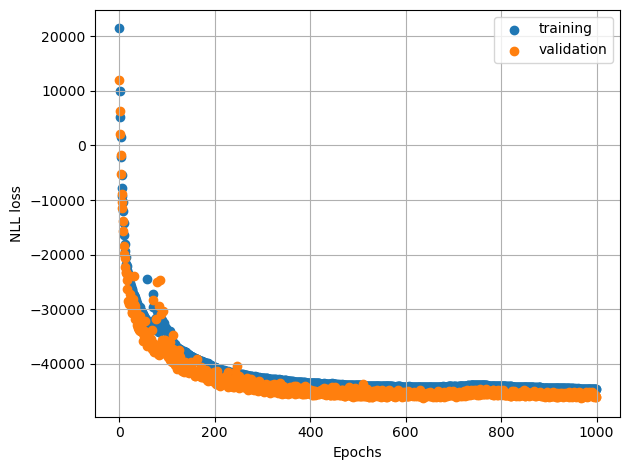

In [9]:
plt.scatter(training_history['epoch'], training_history['loss'])
plt.scatter(training_history['epoch'], training_history['val_loss'])
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

plt.savefig(os.path.join(base_dir,'training_hist.png'))
plt.show()

Current k: 61.4550
Final Learned Levels: [-1.         -0.3333333   0.33333337  1.        ]
Final Learned Thresholds: [-0.9192512   0.07680714  0.57493377]
- log_k: 4.1183
- first_level: [-1.]
- log_level_deltas: [-0.40546507 -0.40546507 -0.4054652 ]
- first_threshold: [-0.9192512]
- log_threshold_deltas: [-0.00394942 -0.69690084]


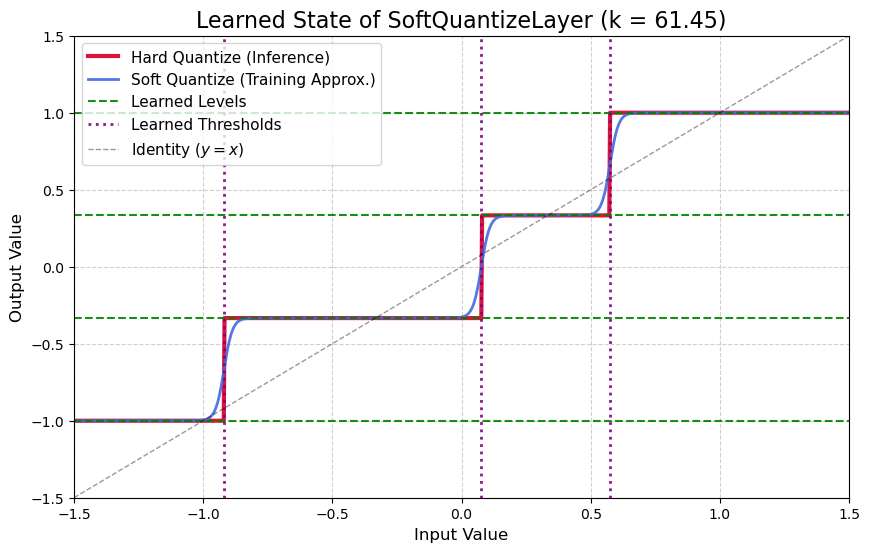

In [10]:
sq_layer = model.get_layer(name="soft_quantizer_output")

current_k = sq_layer.k.numpy().item()
final_levels = sq_layer.levels.numpy()
final_thresholds = sq_layer.thresholds.numpy()

print(f"Current k: {current_k:.4f}")
print(f"Final Learned Levels: {final_levels}")
print(f"Final Learned Thresholds: {final_thresholds}")
print(f"- log_k: {sq_layer.log_k.numpy().item():.4f}")
print(f"- first_level: {sq_layer.first_level.numpy()}")
print(f"- log_level_deltas: {sq_layer.log_level_deltas.numpy()}")
print(f"- first_threshold: {list(sq_layer.first_threshold.numpy())}")
print(f"- log_threshold_deltas: {sq_layer.log_threshold_deltas.numpy()}")

x_input = tf.constant(np.linspace(-1.5, 1.5, 1000), dtype=tf.float32)
y_hard = sq_layer._hard_quantize(x_input, final_levels, final_thresholds)
y_soft = sq_layer._soft_quantize(x_input, current_k, final_levels, final_thresholds)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_input, y_hard, color='crimson', linewidth=3, label='Hard Quantize (Inference)')
ax.plot(x_input, y_soft, color='royalblue', linestyle='-', linewidth=2, alpha=0.9, label='Soft Quantize (Training Approx.)')

ax.hlines(final_levels, xmin=-1.5, xmax=1.5, colors='green', linestyles='--', lw=1.5, alpha=0.9, label='Learned Levels')
ax.vlines(final_thresholds, ymin=-1.5, ymax=1.5, colors='purple', linestyles=':', lw=2, alpha=0.9, label='Learned Thresholds')
ax.plot(x_input, x_input, 'k--', alpha=0.4, lw=1, label='Identity ($y=x$)')

ax.set_title(f"Learned State of SoftQuantizeLayer (k = {current_k:.2f})", fontsize=16)
ax.set_xlabel("Input Value", fontsize=12)
ax.set_ylabel("Output Value", fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.show()

In [11]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained"
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [12]:
test_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=True,
)
labels_scale = test_generator.labels_scale
print(labels_scale)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained/TFR_files/2t/TFR_val/metadata.json
[99.17029747 24.79370923  6.53245764  1.89031215]


In [13]:
def map_normalized_to_raw_charge(model, data_generator):
    """Map soft quantization thresholds & levels from normalized to raw charge space"""
    
    # Extract soft quantization parameters
    sq_layer = model.get_layer(name="soft_quantizer_output")
    thresholds = sq_layer.thresholds.numpy()
    
    # Get normalization parameters from data generator
    mu, sigma = data_generator.dataset_mean[0], data_generator.dataset_std[0] 
    s_pos, s_neg = data_generator.norm_factor_pos, data_generator.norm_factor_neg
    
    def reverse_transform(norm_vals):
        """Reverse the full normalization pipeline"""
        # Step 1: Reverse asymmetric scaling
        scaled_back = np.where(norm_vals > 0, norm_vals * s_pos, norm_vals * s_neg)
        
        # Step 2: Reverse standardization  
        log_vals = scaled_back * sigma + mu
        
        # Step 3: Reverse log compression: x_raw = sign(x_log) * (2^|x_log| - 1)
        raw_charges = np.sign(log_vals) * (2**np.abs(log_vals) - 1)
        
        return raw_charges
    
    # Apply reverse transformation
    raw_thresholds = reverse_transform(thresholds)

    print("QUANTIZATION THRESHOLDS:")
    for i, (norm, raw) in enumerate(zip(thresholds, raw_thresholds)):
        print(f"  Threshold {i+1}: {norm:8.3f} → {raw:10.1f}")

    print(f"\nNormalization params: μ={mu:.3f}, σ={sigma:.3f}, s+={s_pos:.3f}, s-={s_neg:.3f}")
    
    return raw_thresholds

In [14]:
raw_thresholds = map_normalized_to_raw_charge(model, test_generator)

QUANTIZATION THRESHOLDS:
  Threshold 1:   -0.919 →     -418.2
  Threshold 2:    0.077 →       32.7
  Threshold 3:    0.575 →      789.6

Normalization params: μ=4.374, σ=5.802, s+=1.575, s-=2.454


In [15]:
# predicts test data
p_test = model.predict(test_generator)

21/21 [==============================] - 3s 84ms/step


In [16]:
complete_truth = None
for _, y in tqdm(test_generator):
        if complete_truth is None:
            complete_truth = y
        else:
            complete_truth = np.concatenate((complete_truth, y), axis=0)

100%|██████████| 21/21 [00:01<00:00, 11.05it/s]


In [17]:
def softplus(x):
    x = np.asarray(x)
    return np.maximum(x, 0) + np.log1p(np.exp(-np.abs(x)))

In [18]:
# creates df with all predicted values and matrix elements - 4 predictions, all 10 unique matrix elements
df = pd.DataFrame(p_test,columns=['x','M11','y','M22','cotA','M33','cotB','M44','M21','M31','M32','M41','M42','M43'])

# stores all true values in same matrix as xtrue, ytrue, etc.
df['xtrue'] = complete_truth[:,0]
df['ytrue'] = complete_truth[:,1]
df['cotAtrue'] = complete_truth[:,2]
df['cotBtrue'] = complete_truth[:,3]
df['M11'] = minval+tf.math.maximum(df['M11'], 0)
df['M22'] = minval+tf.math.maximum(df['M22'], 0)
df['M33'] = minval+tf.math.maximum(df['M33'], 0)
df['M44'] = minval+tf.math.maximum(df['M44'], 0)

df['sigmax'] = abs(df['M11'])
df['sigmay'] = np.sqrt(df['M21']**2 + df['M22']**2)
df['sigmacotA'] = np.sqrt(df['M31']**2+df['M32']**2+df['M33']**2)
df['sigmacotB'] = np.sqrt(df['M41']**2+df['M42']**2+df['M43']**2+df['M44']**2)

# calculates residuals for x, y, cotA, cotB
residuals = df['xtrue'] - df['x']
residualsy = df['ytrue'] - df['y']
residualsA = df['cotAtrue'] - df['cotA']
residualsB = df['cotBtrue'] - df['cotB']

# stores results as csv
df.to_csv("test_4x4.csv",header=True,index=False)

# residuals (mean, stdv)

In [19]:
# x
(np.mean(residuals)*labels_scale[0],np.std(residuals)*labels_scale[0])

(1.0658330257711328, 4.888323177388119)

In [20]:
# y
(np.mean(residualsy)*labels_scale[1],np.std(residualsy)*labels_scale[1])

(0.11190373444482042, 1.3707622229588066)

In [21]:
# cotA
(np.mean(residualsA)*labels_scale[2],np.std(residualsA)*labels_scale[2])

(-0.010231568207975843, 0.1308568273902272)

In [22]:
# cotB
(np.mean(residualsB)*labels_scale[3],np.std(residualsB)*labels_scale[3])

(0.004517625167415756, 0.03906514768923983)

# x residuals

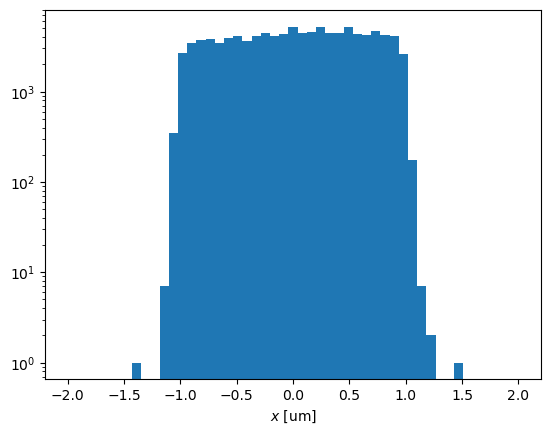

In [23]:
plt.hist(p_test[:,0],bins=np.linspace(-2,2,50))
plt.yscale('log')
plt.xlabel(r'$x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_dist.png')
plt.savefig(save_fig_path)

plt.show()

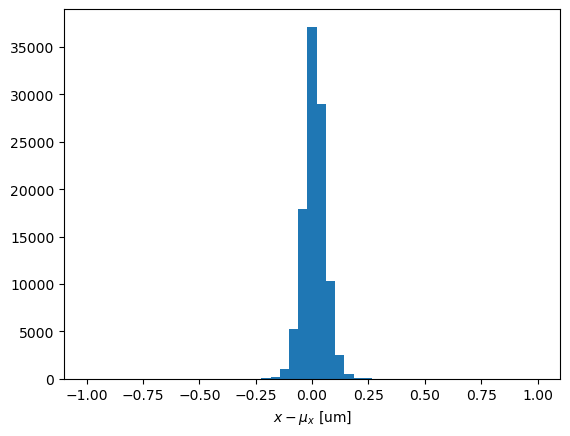

In [24]:
plt.hist(residuals,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

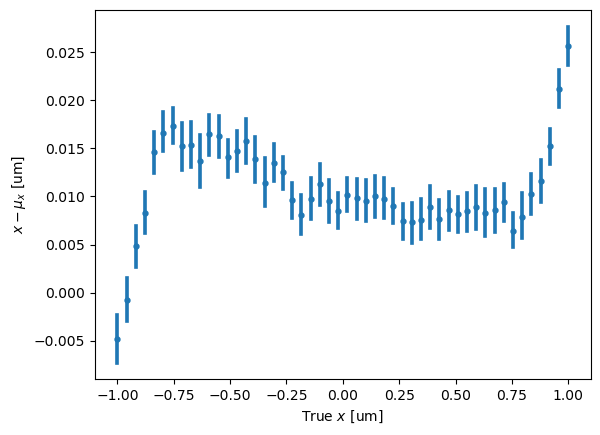

In [25]:
x = sns.regplot(x=df['xtrue'], y=(df['xtrue']-df['x']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $x$ [um]')
plt.ylabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# y residuals

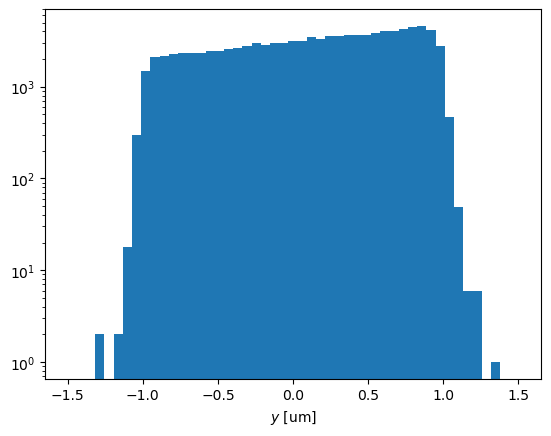

In [26]:
plt.hist(p_test[:,2],bins=np.linspace(-1.5,1.5,50))
plt.yscale('log')
plt.xlabel(r'$y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_dist.png')
plt.savefig(save_fig_path)

plt.show()

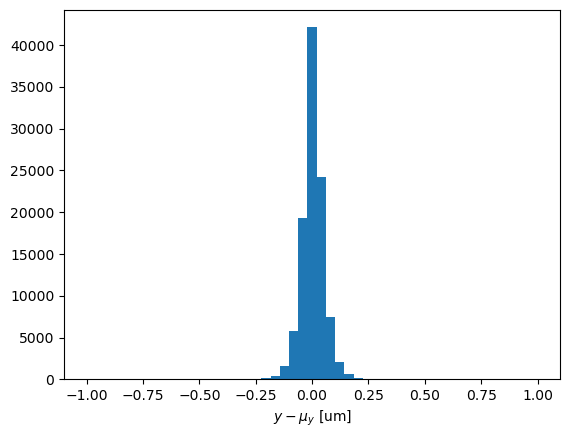

In [27]:
plt.hist(residualsy,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

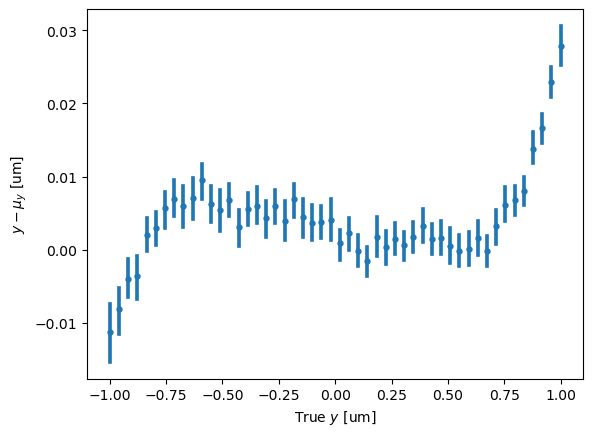

In [28]:
x = sns.regplot(x=df['ytrue'], y=(df['ytrue']-df['y']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $y$ [um]')
plt.ylabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotA residuals

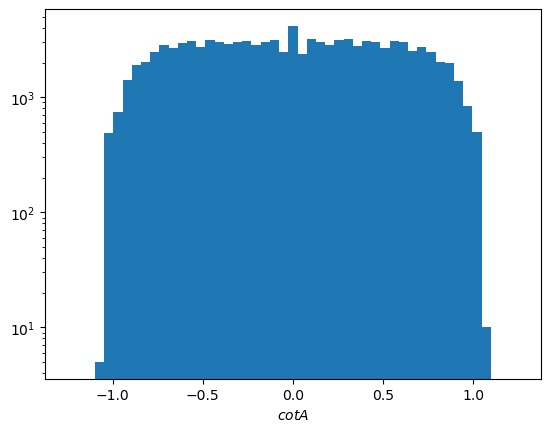

In [29]:
plt.hist(df["cotA"],bins=np.linspace(-1.25,1.25,50))
plt.yscale('log')
plt.xlabel(r'$cotA$')

save_fig_path = os.path.join(plot_dir, 'cotA_dist.png')
plt.savefig(save_fig_path)

plt.show()

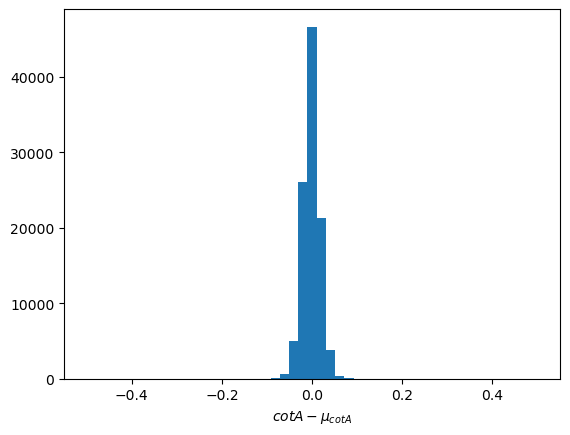

In [30]:
plt.hist(residualsA,bins=np.linspace(-0.5,0.5,50))
#plt.yscale('Log')
plt.xlabel(r'$cotA-\mu_{cotA}$')

save_fig_path = os.path.join(plot_dir, 'cotA_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

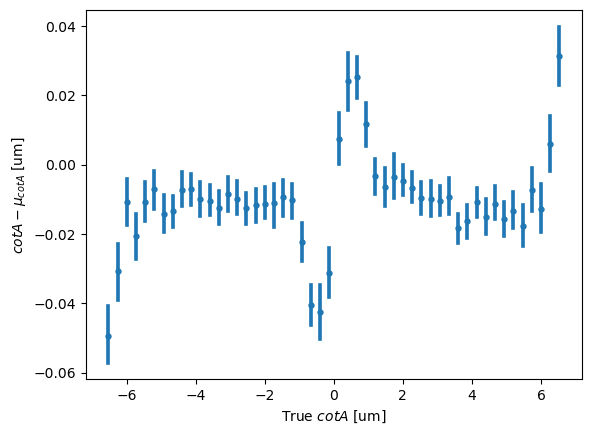

In [31]:
x = sns.regplot(x=df['cotAtrue']*labels_scale[2], y=(df['cotAtrue']-df['cotA'])*labels_scale[2], x_bins=np.linspace(-labels_scale[2],labels_scale[2],50), fit_reg=None, marker='.')
plt.xlabel(r'True $cotA$ [um]')
plt.ylabel(r'$cotA-\mu_{cotA}$ [um]')

save_fig_path = os.path.join(plot_dir, 'cotA_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotB residuals

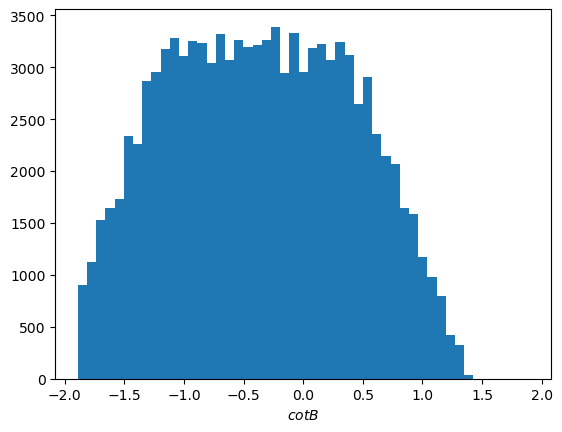

In [32]:
plt.hist(df["cotB"]*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB$')

save_fig_path = os.path.join(plot_dir, 'cotB_dist.png')
plt.savefig(save_fig_path)

plt.show()

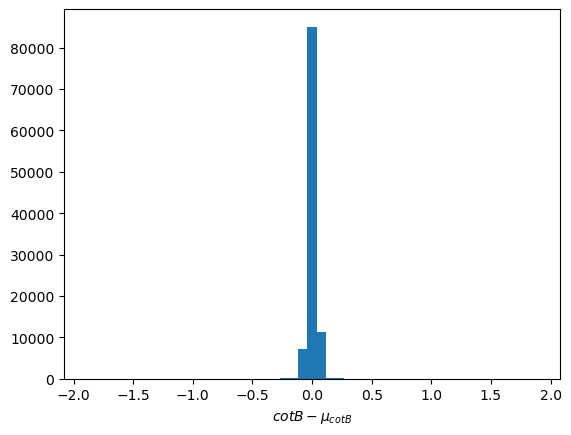

In [33]:
plt.hist(residualsB*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB-\mu_{cotB}$')

save_fig_path = os.path.join(plot_dir, 'cotB_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

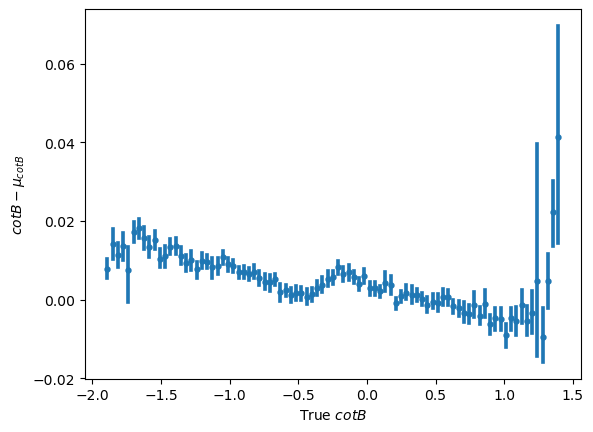

In [34]:
x = sns.regplot(x=df['cotBtrue']*labels_scale[3], y=(df['cotBtrue']-df['cotB'])*labels_scale[3], x_bins=np.linspace(-labels_scale[3],labels_scale[3],100), fit_reg=None, marker='.')
plt.xlabel(r'True $cotB$')
plt.ylabel(r'$cotB-\mu_{cotB} $')

save_fig_path = os.path.join(plot_dir, 'cotB_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# pull

In [35]:
df['pullx'] = (df['xtrue']-df['x'])/df['sigmax']
df['pully'] = (df['ytrue']-df['y'])/df['sigmay']
df['pullcotA'] = (df['cotAtrue']-df['cotA'])/df['sigmacotA']
df['pullcotB'] = (df['cotBtrue']-df['cotB'])/df['sigmacotB']

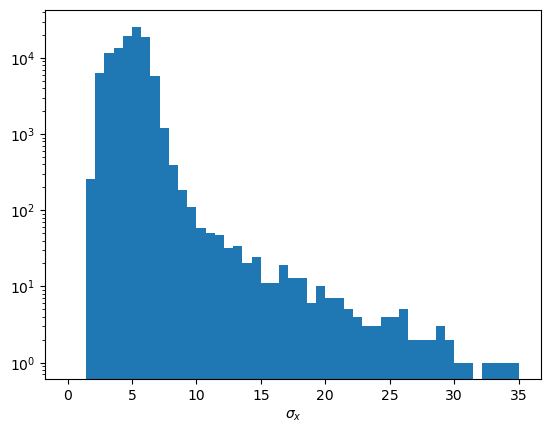

In [36]:
plt.hist(df['sigmax'] *labels_scale[0],bins=np.linspace(0,35,50))
plt.xlabel('$\sigma_{x}$')
plt.yscale('log')

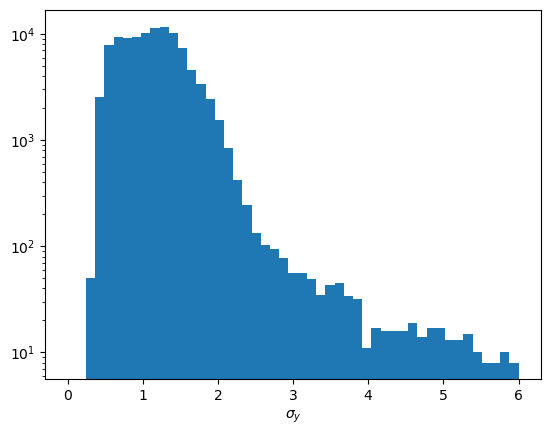

In [37]:
plt.hist(df['sigmay']*labels_scale[1],bins=np.linspace(0,6,50))
plt.xlabel('$\sigma_{y}$')
plt.yscale('log')

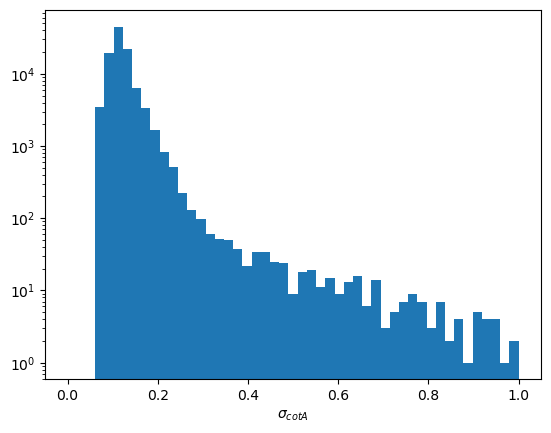

In [38]:
plt.hist(df['sigmacotA'] *labels_scale[2],bins=np.linspace(0,1.0,50))
plt.xlabel('$\sigma_{cotA}$')
plt.yscale('log')

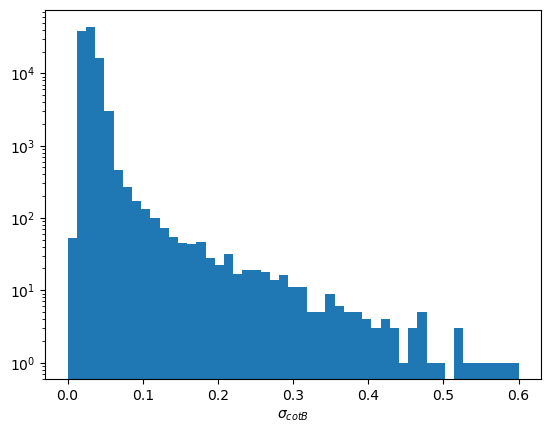

In [39]:
plt.hist(df['sigmacotB'] *labels_scale[3] ,bins=np.linspace(0,0.6,50))
plt.xlabel('$\sigma_{cotB}$')
plt.yscale('log')

In [40]:
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def pull_plot(ax, var, name):
    
    h = ax.hist(df[var],bins=np.linspace(-5,5,50),histtype='step')
    ax.set_xlabel(name)
    ax.set_yscale('log')

    ydata = h[0]
    xdata = h[1][:-1]+3/50.

    pars, cov = curve_fit(gauss,xdata,ydata)

    xbins = np.linspace(-5,5,100)
    ax.plot(xbins,gauss(xbins,pars[0],pars[1],pars[2]),color='black')
    ax.set_ylim(0.5,100000)

    print('Mean',pars[1])
    print('Sigma',pars[2])
    
    ax.text(-5,2000,"$\mu$="+str(round(pars[1],2)))
    ax.text(-5,1000,"$\sigma$="+str(round(abs(pars[2]),2)))

# Pull Plot

Mean 0.19454736257704217
Sigma -0.9204217876451464
Mean 0.06613826862281447
Sigma 0.9282508090148867
Mean -0.13337434525165662
Sigma 0.9670052186853136
Mean 0.1347701418507659
Sigma -0.9652086167319996


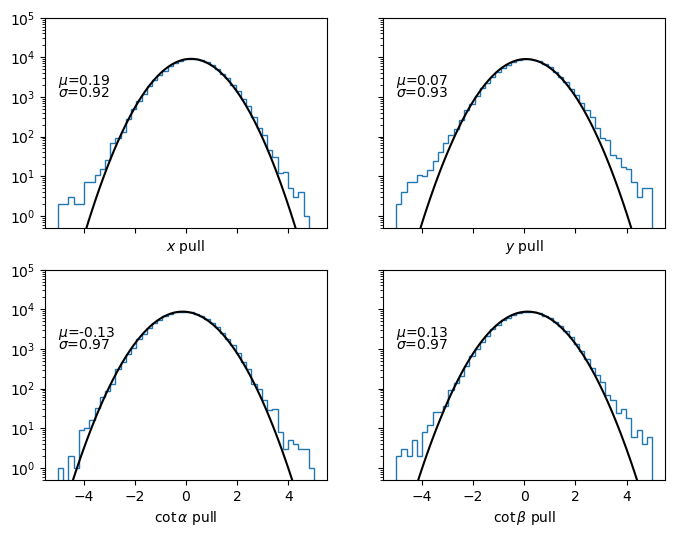

In [41]:
fig, axes = plt.subplots(2,2,sharex=True,sharey=True,figsize=(8,6))
pull_plot(axes[0][0],'pullx',r'$x$ pull')
pull_plot(axes[0][1],'pully',r'$y$ pull')
pull_plot(axes[1][0],'pullcotA',r'$\cot\alpha$ pull')
pull_plot(axes[1][1],'pullcotB',r'$\cot\beta$ pull')

save_fig_path = os.path.join(plot_dir, 'Pull.png')
plt.savefig(save_fig_path)

plt.show()

# Summary

In [42]:
def residual_plot(ax, thisdf, var1, var2, name, scaling=1.0):
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = residual_scaled
    print(var1)
    
    means = []
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

def inverse_cot(cota):
    a = np.arctan(1.0/cota)
    a[np.where(a<0)] = a[np.where(a<0)] + pi
    return a    

def residual_plot_deg(ax, thisdf, var1, var2, name, scaling=1.0):
    # positions
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
        return

    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
    
    thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
        
    var1 = 'angletrue'
    var2 = 'angle'
    
    nbins = 15
    xmin = np.min(thisdf[var1])
    xmax = np.max(thisdf[var1])
    
    step = 1.0*(xmax-xmin)/nbins
        
    x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
    print(var1)
    
    means = []    
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
    #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

# Summary Plot

xtrue
ytrue
angletrue
angletrue


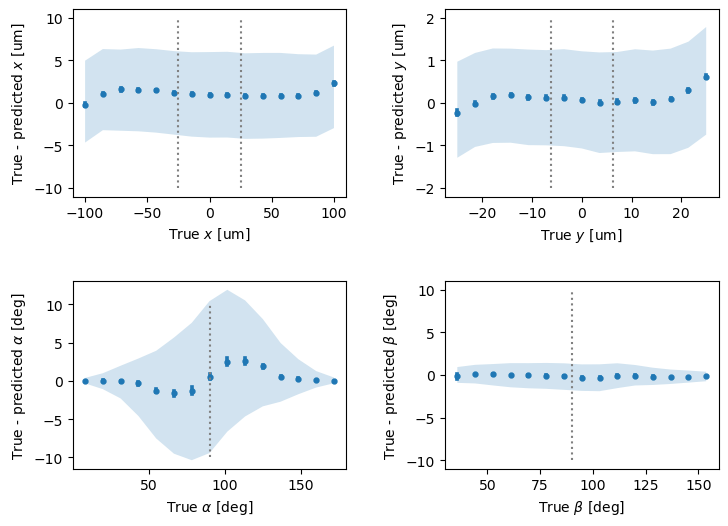

In [43]:
fig, axes = plt.subplots(2,2,figsize=(8,6))
fig.tight_layout(pad=4.0)
residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]', scaling=labels_scale[0])
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]', scaling=labels_scale[1])
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df,'cotAtrue','cotA',r'$\alpha$ [deg]', scaling=labels_scale[2])
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df,'cotBtrue','cotB',r'$\beta$ [deg]', scaling=labels_scale[3])
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

save_fig_path = os.path.join(plot_dir, 'summary.png')
plt.savefig(save_fig_path)